<a href="https://colab.research.google.com/github/Shmadhi/Appendicitis_Prediction_using_RandomForest/blob/main/CKD_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Can Routine CBC and Basic Physical Exams Flag Early CKD Risk?

**Data Source:** UCI Machine Learning Repository
**Dataset:** Hospital patients collected over 2 months period (before July 2015)  
**Sample size:** 400 Patients from Tamil Nadu, India

**Cases:** 250 CKD patients + 150 healthy controls  

**Features:** 25 clinical attributes (age, lab tests, comorbidities)



Prepeared by: [Shaykhah Almadhi](https://www.linkedin.com/in/shaykhah-a/)

## Step 1: Setup

In [ ]:
# install packages
!pip install -q pandas numpy scikit-learn shap matplotlib seaborn ucimlrepo
!pip install phik

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split

from ucimlrepo import fetch_ucirepo
import phik
import shap
import os

os.makedirs("workshop_outputs", exist_ok=True)

print('Libraries loaded')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 21.2 MB/s eta 0:00:00
Libraries loaded


## Step 2: Load the Data from UCI

In [ ]:
# 1. Fetch data
dataset = fetch_ucirepo(id=336)

# 2. Features and target
X = dataset.data.features.copy().apply(lambda s: s.str.strip() if s.dtype == "object" else s) #Features
y = dataset.data.targets.iloc[:, 0].str.strip().map({"ckd": 1, "notckd": 0}) #target

# 3. Feature descriptions
var_desc = dataset.variables.set_index("name")["description"].to_dict()

# 4. Create raw DataFrame for EDA + use descriptive names
df_raw = X.rename(columns=lambda c: var_desc.get(c) or c).copy()
df_raw["class"] = y.map({1: "CKD", 0: "NotCKD"}) # Add target labels
for col in df_raw.select_dtypes(include="object").columns: # lean whitespace in categorical variables
    df_raw[col] = df_raw[col].str.strip()


# transform Original Features to one-hot encoding
X = pd.get_dummies(X, drop_first=True)

#Does our data make sense?

## Step 3: Exploratory Analysis

Descriptive Statistics:
          age  blood pressure  specific gravity  albumin  sugar  \
count   391.0           388.0             353.0    354.0  351.0   
unique    NaN             NaN               NaN      NaN    NaN   
top       NaN             NaN               NaN      NaN    NaN   
freq      NaN             NaN               NaN      NaN    NaN   
mean     51.5            76.5               1.0      1.0    0.5   
std      17.2            13.7               0.0      1.4    1.1   
min       2.0            50.0               1.0      0.0    0.0   
25%      42.0            70.0               1.0      0.0    0.0   
50%      55.0            80.0               1.0      0.0    0.0   
75%      64.5            80.0               1.0      2.0    0.0   
max      90.0           180.0               1.0      5.0    5.0   

       red blood cells pus cell pus cell clumps    bacteria  \
count              248      335             396         396   
unique               2        2              

/tmp/ipykernel_3413/1151421867.py:19: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_raw, x=var, hue="class", fill=True, ax=ax)


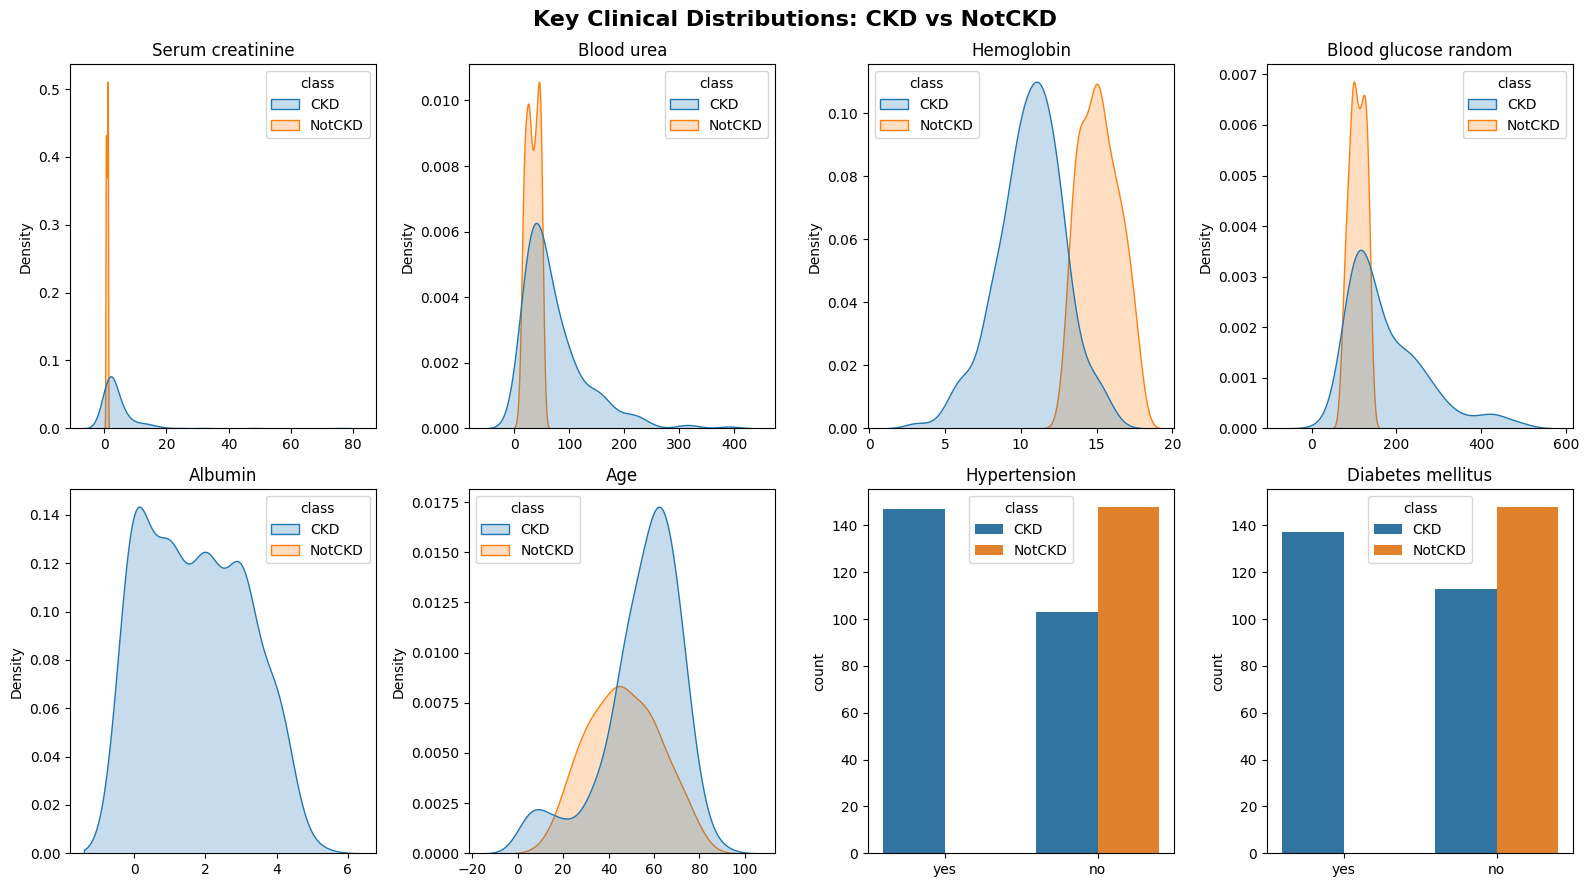

In [ ]:
# Descriptive stats
pd.set_option("display.max_columns", None)
print("Descriptive Statistics:")
print(df_raw.describe(include="all").round(1))
df_raw.describe(include="all").round(1).to_csv("workshop_outputs/descriptive_statistics.csv")

# Inspect missing values
print(df_raw.isna().sum().sort_values(ascending=False))

# Inspect types of data
print("types of data")
print(df_raw.dtypes.value_counts())

# Plot Statistical plots
features = ["serum creatinine", "blood urea", "hemoglobin", "blood glucose random","albumin", "age", "hypertension", "diabetes mellitus"]
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, var in zip(axes.flat, features):
    if pd.api.types.is_numeric_dtype(df_raw[var]):
        sns.kdeplot(data=df_raw, x=var, hue="class", fill=True, ax=ax)
    else:
        sns.countplot(data=df_raw, x=var, hue="class", ax=ax)
    ax.set_title(var.capitalize())
    ax.set_xlabel("")
fig.suptitle("Key Clinical Distributions: CKD vs NotCKD",fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("workshop_outputs/clinical_dashboard.png", dpi=300)
plt.show()

##Can clinicians already separate CKD patients?

interval columns not set, guessing: ['age', 'blood pressure', 'specific gravity', 'albumin', 'sugar', 'blood glucose random', 'blood urea', 'serum creatinine', 'sodium', 'potassium', 'hemoglobin', 'packed cell volume', 'white blood cell count', 'red blood cell count']


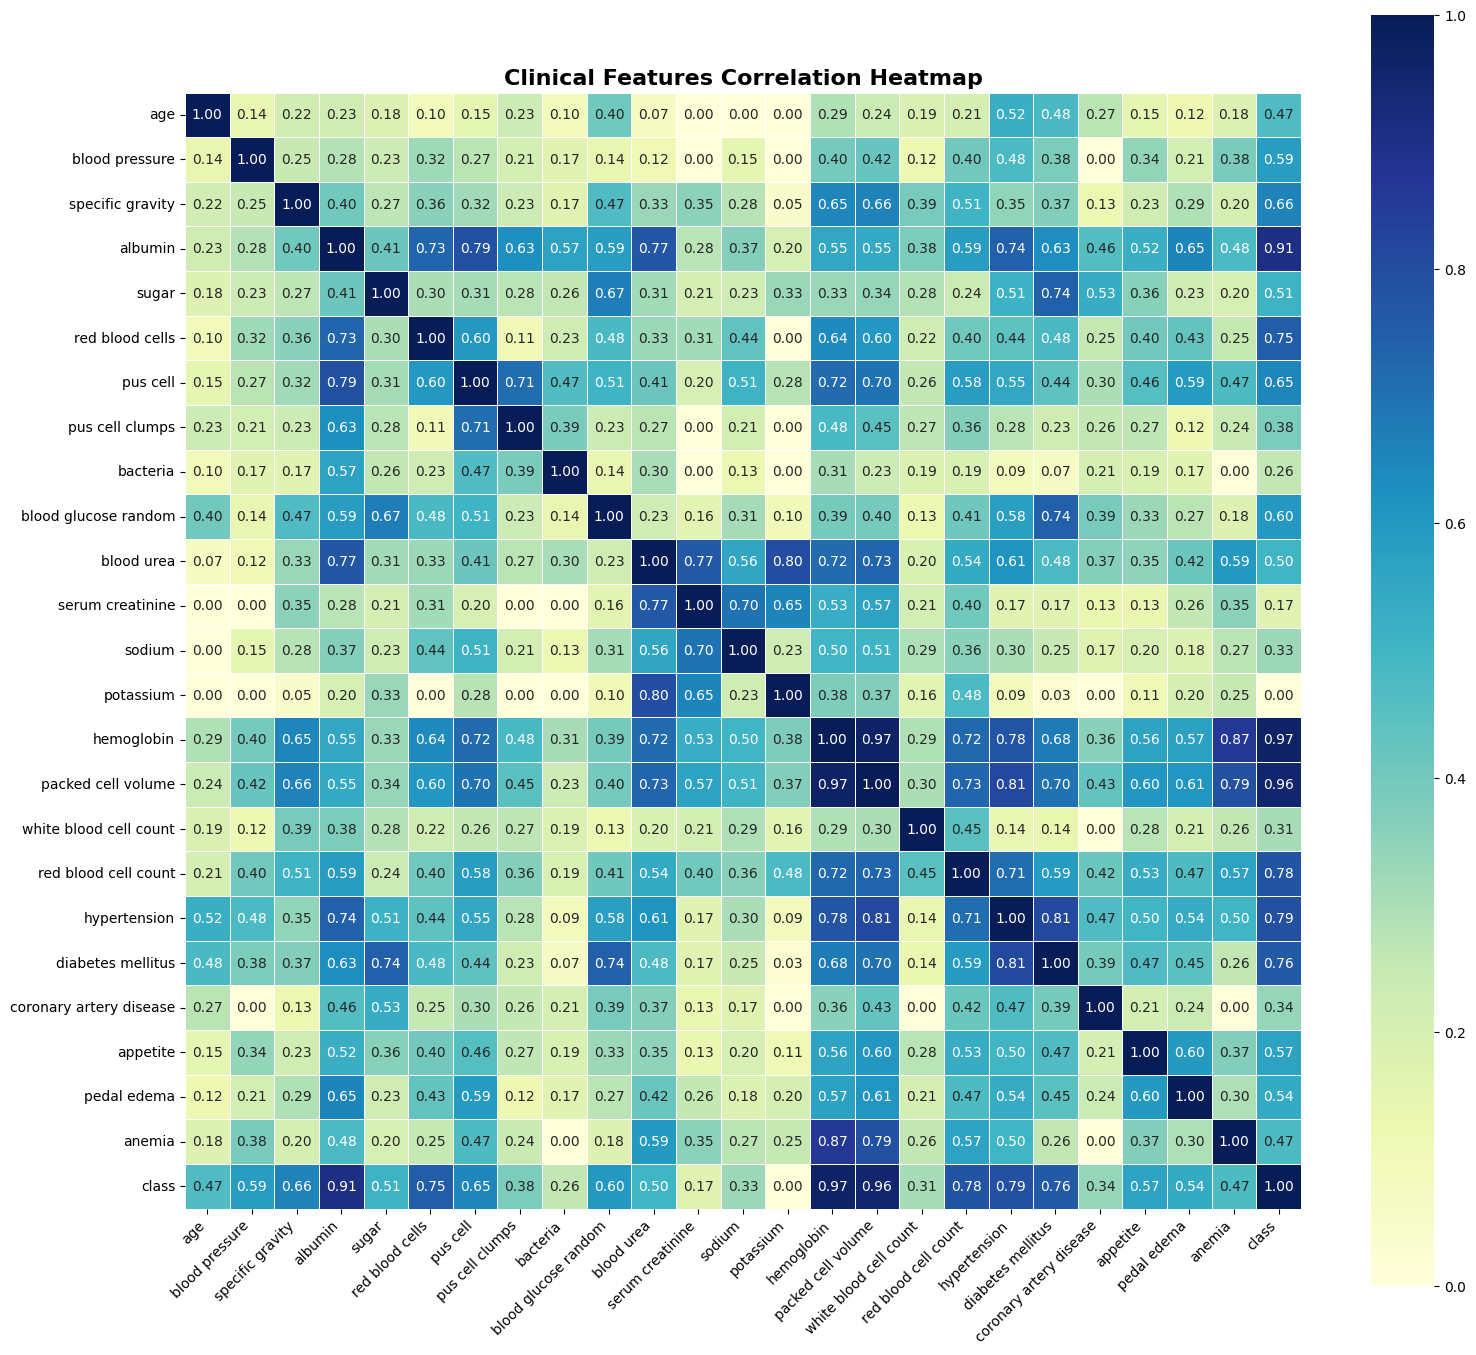

In [ ]:
# Correlation heatmap (all features)
phik_matrix = df_raw.phik_matrix() # Calculate the phik correlation matrix for all features

plt.figure(figsize=(16, 14)) # Plot the heatmap
sns.heatmap(phik_matrix,annot=True,fmt=".2f",vmin=0,vmax=1,square=True,linewidths=0.5,cmap="YlGnBu")
plt.title("Clinical Features Correlation Heatmap", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("workshop_outputs/phik_features_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 4: Model Training and Testing

In [ ]:
# filter X to include basic history, CBC, and before urine test
X_prescreen = X[['age', 'bp', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn_yes', 'dm_yes', 'cad_yes', 'appet_poor', 'pe_yes', 'ane_yes']] if 'htn_yes' in X.columns else X[['age', 'bp', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']]

# split
X_train, X_test, y_train, y_test = train_test_split(X_prescreen, y, test_size=0.3, stratify=y, random_state=2026)

# impute missing values
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns,index=X_train.index) # fit transform
X_test = pd.DataFrame(imputer.transform(X_test),columns=X_test.columns,index=X_test.index) # only transform

# rename the columns for full describtion
X_train = X_train.rename(columns=lambda c: var_desc.get(c) or c)
X_test = X_test.rename(columns=lambda c: var_desc.get(c) or c)

# model
model = RandomForestClassifier(n_estimators=100, max_depth=3, min_samples_leaf=15, max_features="sqrt", class_weight="balanced", random_state=2026, n_jobs=-1)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # for ROC curve data

## Step 5: Performance Evaluation


Clinical Pre-Screening Risk Assessment Report

              precision    recall  f1-score   support

     Healthy       0.90      1.00      0.95        45
         CKD       1.00      0.93      0.97        75

    accuracy                           0.96       120
   macro avg       0.95      0.97      0.96       120
weighted avg       0.96      0.96      0.96       120

Pre-Screening Screening Tool Test ROC AUC: 0.9935


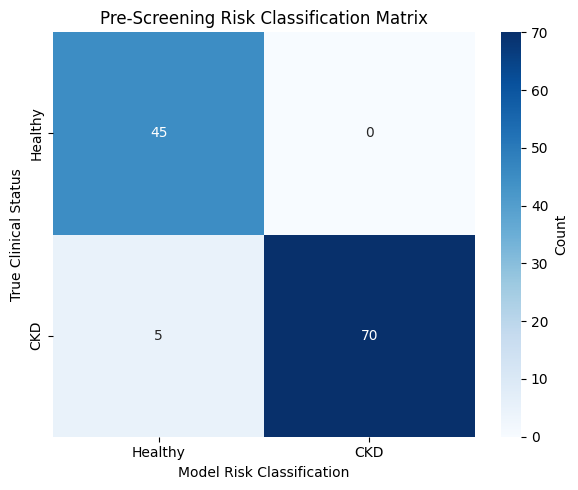

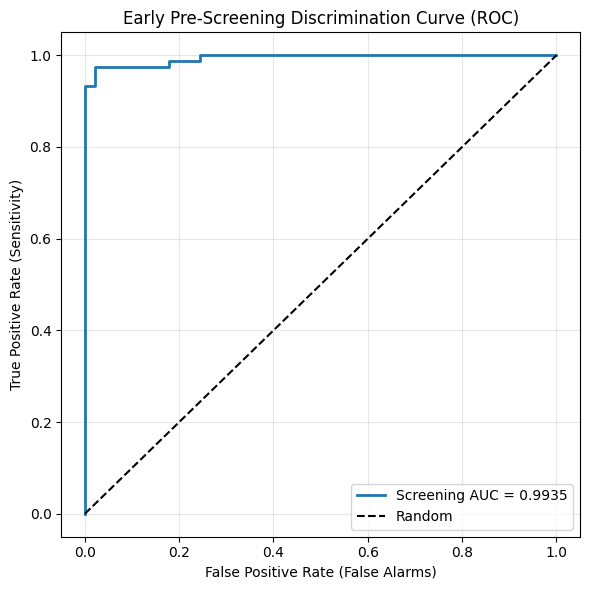

In [ ]:
# evaluate out "Pre-Screening" model and read metrics
# Classification report
print("\nClinical Pre-Screening Risk Assessment Report\n")
print(classification_report(y_test, y_pred, target_names=["Healthy", "CKD"]))
print(f"Pre-Screening Screening Tool Test ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion matrix
plt.figure(figsize=(6, 5));
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",xticklabels=["Healthy", "CKD"],yticklabels=["Healthy", "CKD"],cbar_kws={"label": "Count"})
plt.xlabel("Model Risk Classification");
plt.ylabel("True Clinical Status");
plt.title("Pre-Screening Risk Classification Matrix");
plt.savefig("workshop_outputs/cm.png", dpi=300);
plt.tight_layout();
plt.show()

# ROC curve showing screening discrimination power
plt.figure(figsize=(6, 6));
plt.plot(fpr, tpr, linewidth=2, label=f"Screening AUC = {roc_auc_score(y_test, y_prob):.4f}"); plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate (False Alarms)");
plt.ylabel("True Positive Rate (Sensitivity)");
plt.title("Early Pre-Screening Discrimination Curve (ROC)");
plt.legend(loc="lower right");
plt.grid(alpha=0.3);
plt.tight_layout();
plt.savefig("workshop_outputs/roc_auc.png", dpi=300, bbox_inches="tight");
plt.show()

#Why did the model predict CKD?

## Step 7: Feature Importance and SHAP Interpretation

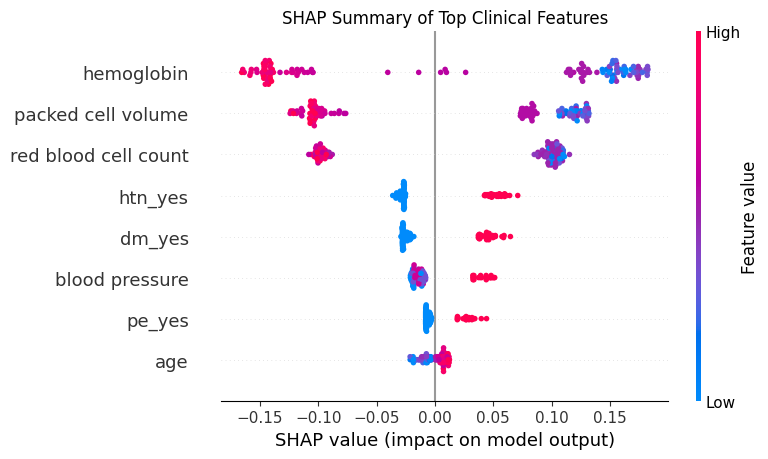

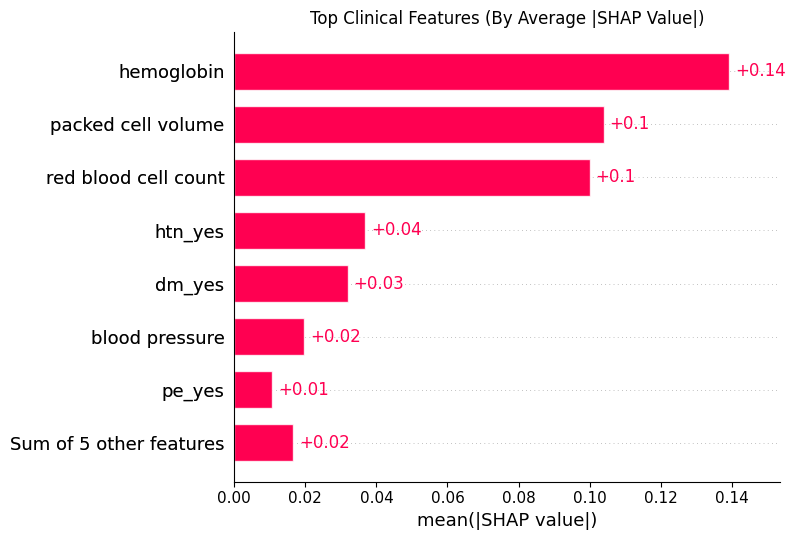

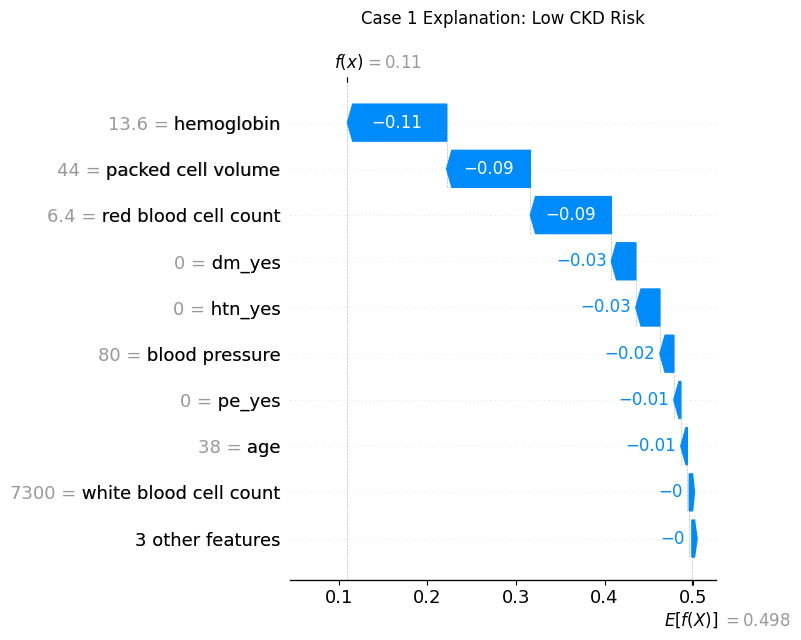

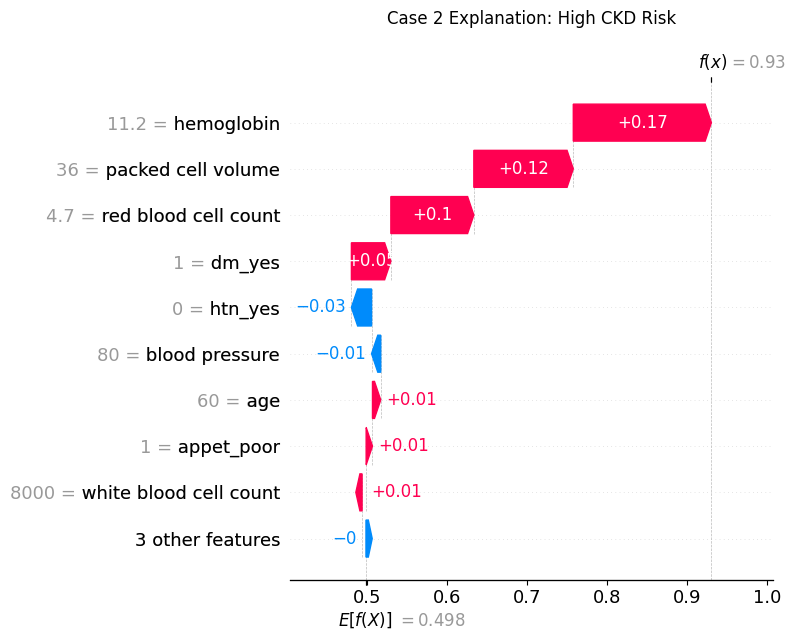

In [ ]:
# Compute SHAP values to for model interpretation
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test, check_additivity=False)

# 1.1 plot beeswarm
shap.plots.beeswarm(shap_values[:, :, 1],max_display=8,group_remaining_features=False,show=False) #[:, :, 1] for CKD-positive. Use [:, :, 0] for healthy class
plt.title("SHAP Summary of Top Clinical Features")
plt.tight_layout()
plt.savefig("workshop_outputs/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

# 1.2 plot bar
shap.plots.bar(shap_values[:, :, 1], max_display=8, show=False);
plt.title("Top Clinical Features (By Average |SHAP Value|)");
plt.tight_layout();
plt.savefig("workshop_outputs/shap_bar.png", dpi=300, bbox_inches="tight");
plt.show()


# Plot for Case 1: Low risk
plt.figure(figsize=(8, 4))
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.title("Case 1 Explanation: Low CKD Risk", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("workshop_outputs/Case_1.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot for Case 2: High risk
plt.figure(figsize=(8, 4))
shap.plots.waterfall(shap_values[1, :, 1], show=False)
plt.title("Case 2 Explanation: High CKD Risk", fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("workshop_outputs/Case_2.png", dpi=300, bbox_inches="tight")
plt.show()

#Would you deploy this?
